In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns

# 한글 폰트 설정
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

pd.set_option("display.max_columns", 50)

# 데이터 로드 및 전처리 (노원구 제외 버전)

In [2]:
# 데이터 로드
clean_path = r"C:\dev\study\eunjeong\SKN18-FINAL-1TEAM\data\processed_office_data_nn.csv"
df = pd.read_csv(clean_path)

print(f"원본 데이터 크기: {len(df)}행")

# 총매물수 컬럼 생성 (거래완료 + 등록매물)
if "총매물수" not in df.columns:
    df["총매물수"] = df["거래완료"] + df["등록매물"]
    
print(f"컬럼 목록: {df.columns.tolist()}")

원본 데이터 크기: 339행
컬럼 목록: ['등록번호', '중개사명', '대표자', '전화번호', '주소', '거래완료', '등록매물', '개설시작일', '개설종료일', '등록일', '상태구분코드', '상태구분명', '지역코드', '지역명', '도로명주소코드', '최종수정일', '총_직원수', '공인중개사수', '중개보조원수', '대표수', '일반직원수', '직원목록_JSON', '직원명단', '총매물수']


In [3]:
# --------------------------------------------------------------------------------
# 2. 표본이 적은 지역 제거 (총매물수 500건 미만)
# --------------------------------------------------------------------------------
threshold_cnt = 500

# 지역별 총매물수 집계
region_counts = df.groupby("지역명")["총매물수"].sum()

# 기준 미만인 지역명 찾기
small_regions = region_counts[region_counts < threshold_cnt].index

# 데이터프레임 필터링
df_filtered = df[~df["지역명"].isin(small_regions)].copy()

print(f"🔍 기준({threshold_cnt}건) 미만 지역 수: {len(small_regions)}개")
print(f"   (제외 목록: {list(small_regions)})")
print(f"✅ 필터링 후 데이터 크기: {len(df_filtered)}행")

# df 업데이트
df = df_filtered

🔍 기준(500건) 미만 지역 수: 0개
   (제외 목록: [])
✅ 필터링 후 데이터 크기: 339행


지역별 통계 (노원구 제외, 소규모 지역 제외):


,mean,std,count,mean_ratio(%),std_ratio(%)
지역명,,,,,
서울특별시 강북구,0.732385,0.243030,6,73.238511,24.303023
서울특별시 은평구,0.685061,0.283754,10,68.506092,28.375437
서울특별시 마포구,0.631434,0.260716,13,63.143419,26.071640
서울특별시 용산구,0.629712,0.352807,17,62.971234,35.280729
서울특별시 송파구,0.616950,0.291581,18,61.694989,29.158079
서울특별시 광진구,0.616149,0.322018,24,61.614921,32.201838
서울특별시 영등포구,0.608095,0.349656,15,60.809481,34.965568
서울특별시 동작구,0.569581,0.275859,14,56.958077,27.585868
서울특별시 서대문구,0.565002,0.406440,6,56.500201,40.644000


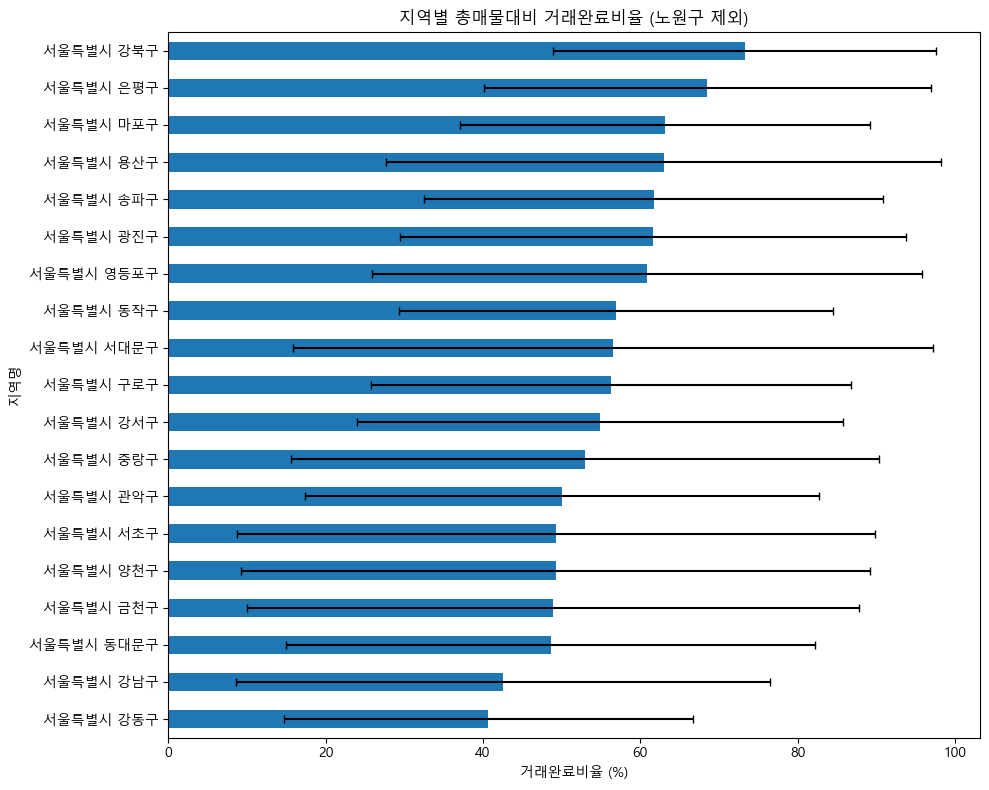

In [4]:
# --------------------------------------------------------------------------------
# 3. 지역별 통계 (평균, 표준편차) 계산 및 시각화
# --------------------------------------------------------------------------------
# 중개사별 거래완료비율 계산
df["거래완료비율"] = df["거래완료"] / df["총매물수"]

# 지역별 집계 (평균, 표준편차, 개수)
region_stats = df.groupby("지역명")["거래완료비율"].agg(["mean", "std", "count"])

# 표준편차 결측치(NaN) 처리: 0으로 대체 (표본 1개인 경우)
# 표본이 1개라 편차가 없는 것이므로 0은 타당한 수치
region_stats["std"] = region_stats["std"].fillna(0)

# % 변환
region_stats["mean_ratio(%)"] = region_stats["mean"] * 100
region_stats["std_ratio(%)"] = region_stats["std"] * 100

print("지역별 통계 (노원구 제외, 소규모 지역 제외):")
display(region_stats.sort_values("mean", ascending=False))

# 시각화
plt.figure(figsize=(10, 8))
region_stats["mean_ratio(%)"].sort_values().plot(
    kind="barh", 
    xerr=region_stats["std_ratio(%)"], 
    capsize=3
)
plt.title("지역별 총매물대비 거래완료비율 (노원구 제외)")
plt.xlabel("거래완료비율 (%)")
plt.tight_layout()
plt.show()

,mean,std,count,trust_score_lcb,trust_weight,listing_share
지역명,,,,,,
서울특별시 강북구,0.732385,0.243030,6,0.489355,1.000000,0.017699
서울특별시 은평구,0.685061,0.283754,10,0.401307,0.781553,0.029499
서울특별시 마포구,0.631434,0.260716,13,0.370718,0.705663,0.038348
서울특별시 송파구,0.616950,0.291581,18,0.325369,0.593153,0.053097
서울특별시 광진구,0.616149,0.322018,24,0.294131,0.515651,0.070796
서울특별시 동작구,0.569581,0.275859,14,0.293722,0.514637,0.041298
서울특별시 용산구,0.629712,0.352807,17,0.276905,0.472914,0.050147
서울특별시 영등포구,0.608095,0.349656,15,0.258439,0.427100,0.044248
서울특별시 구로구,0.562394,0.304784,7,0.257610,0.425043,0.020649


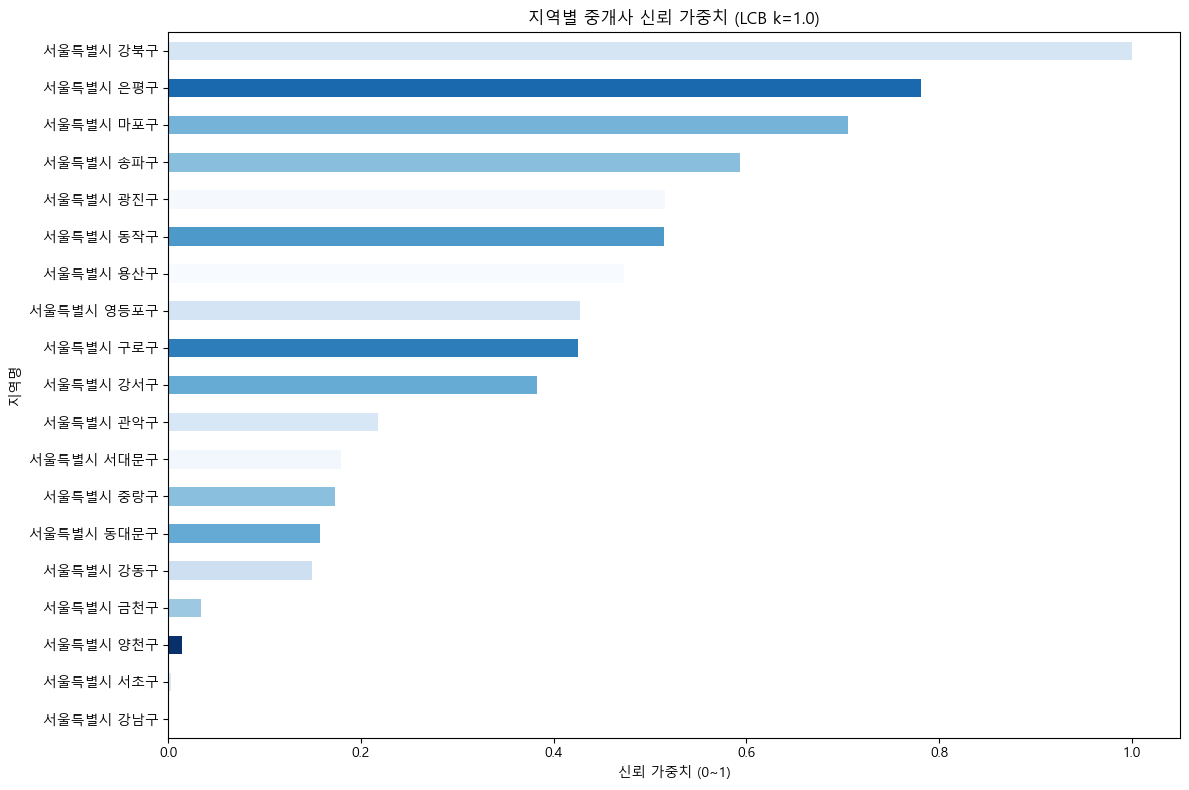

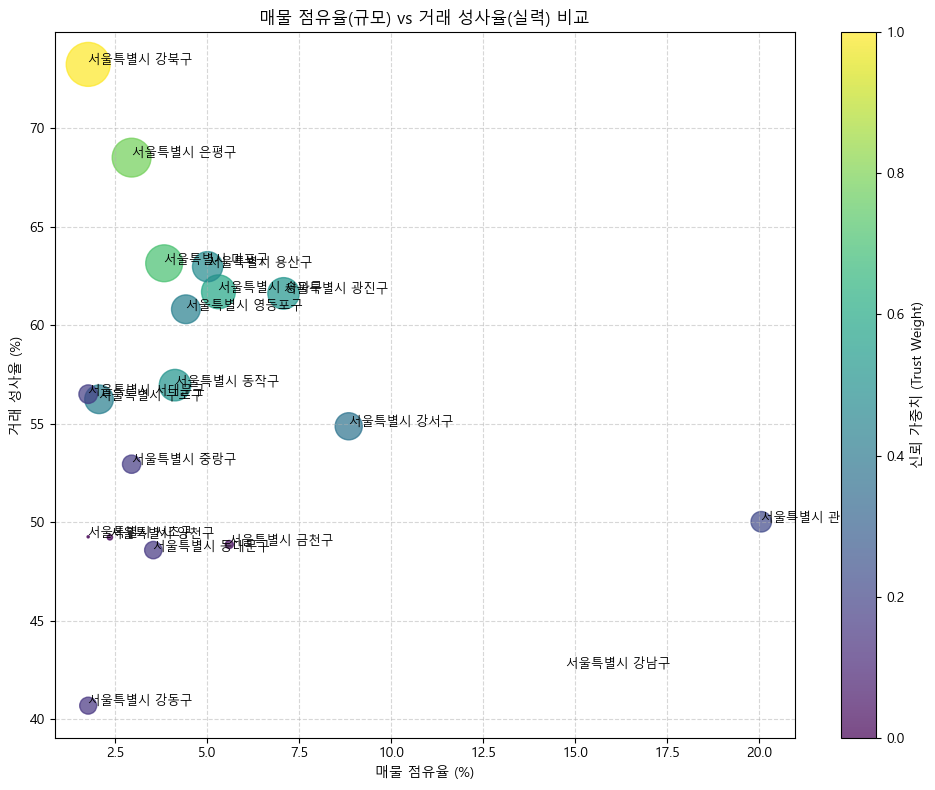

In [5]:
# --------------------------------------------------------------------------------
# 4. 신뢰 가중치(Trust Weight) 및 매물 분포율 계산
# --------------------------------------------------------------------------------

# 1. 신뢰 하한 점수 (Lower Confidence Bound, LCB) 계산
# 점수 = 평균 - (k * 표준편차), k=1.0 (보수적 기준)
# 의미: "최소한 이 정도의 성과율은 기대할 수 있다"
k = 1.0
region_stats["trust_score_lcb"] = region_stats["mean"] - (k * region_stats["std"])

# 음수 보정 (0 미만은 0으로 처리)
region_stats["trust_score_lcb"] = region_stats["trust_score_lcb"].clip(lower=0)

# 정규화 (Min-Max Scaling) -> 0~1 사이 가중치로 변환
min_score = region_stats["trust_score_lcb"].min()
max_score = region_stats["trust_score_lcb"].max()
region_stats["trust_weight"] = (region_stats["trust_score_lcb"] - min_score) / (max_score - min_score)


# 2. 매물 분포율 (Listing Share) 계산
total_listings = region_stats["count"].sum()
region_stats["listing_share"] = region_stats["count"] / total_listings


# --------------------------------------------------------------------------------
# 5. 시각화 및 비교 분석
# --------------------------------------------------------------------------------
display(region_stats[["mean", "std", "count", "trust_score_lcb", "trust_weight", "listing_share"]].sort_values("trust_weight", ascending=False))

fig, ax1 = plt.subplots(figsize=(12, 8))

# (1) 신뢰 가중치 (Trust Weight) 막대 그래프
colors = plt.cm.Blues(region_stats["trust_weight"])
region_stats["trust_weight"].sort_values().plot(kind="barh", color=colors, ax=ax1)
ax1.set_title(f"지역별 중개사 신뢰 가중치 (LCB k={k})")
ax1.set_xlabel("신뢰 가중치 (0~1)")

plt.tight_layout()
plt.show()

# (2) 비교 분석: 매물 규모(Volume) vs 성과(Performance) 산점도
plt.figure(figsize=(10, 8))
plt.scatter(
    region_stats["listing_share"] * 100,  # X축: 매물 점유율 (%)
    region_stats["mean"] * 100,           # Y축: 거래 성사율 (%)
    s=region_stats["trust_weight"] * 1000, # 점 크기: 신뢰 가중치
    alpha=0.7,
    c=region_stats["trust_weight"],       # 색상: 신뢰 가중치
    cmap="viridis"
)

# 지역명 텍스트 표시
for idx, row in region_stats.iterrows():
    plt.text(row["listing_share"]*100, row["mean"]*100, idx, fontsize=9)

plt.title("매물 점유율(규모) vs 거래 성사율(실력) 비교")
plt.xlabel("매물 점유율 (%)")
plt.ylabel("거래 성사율 (%)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.colorbar(label="신뢰 가중치 (Trust Weight)")
plt.tight_layout()
plt.show()

가중치 보정 기준(m): 매물 13.0건, 전체 평균(C): 55.7%


,mean,std,count,listing_share,trust_weight,bayesian_corrected_mean
지역명,,,,,,
서울특별시 강북구,0.732385,0.243030,6,0.017699,1.000000,0.612540
서울특별시 은평구,0.685061,0.283754,10,0.029499,0.781553,0.612807
서울특별시 마포구,0.631434,0.260716,13,0.038348,0.705663,0.594330
서울특별시 송파구,0.616950,0.291581,18,0.053097,0.593153,0.591904
서울특별시 광진구,0.616149,0.322018,24,0.070796,0.515651,0.595447
서울특별시 동작구,0.569581,0.275859,14,0.041298,0.514637,0.563632
서울특별시 용산구,0.629712,0.352807,17,0.050147,0.472914,0.598302
서울특별시 영등포구,0.608095,0.349656,15,0.044248,0.427100,0.584477
서울특별시 구로구,0.562394,0.304784,7,0.020649,0.425043,0.559035


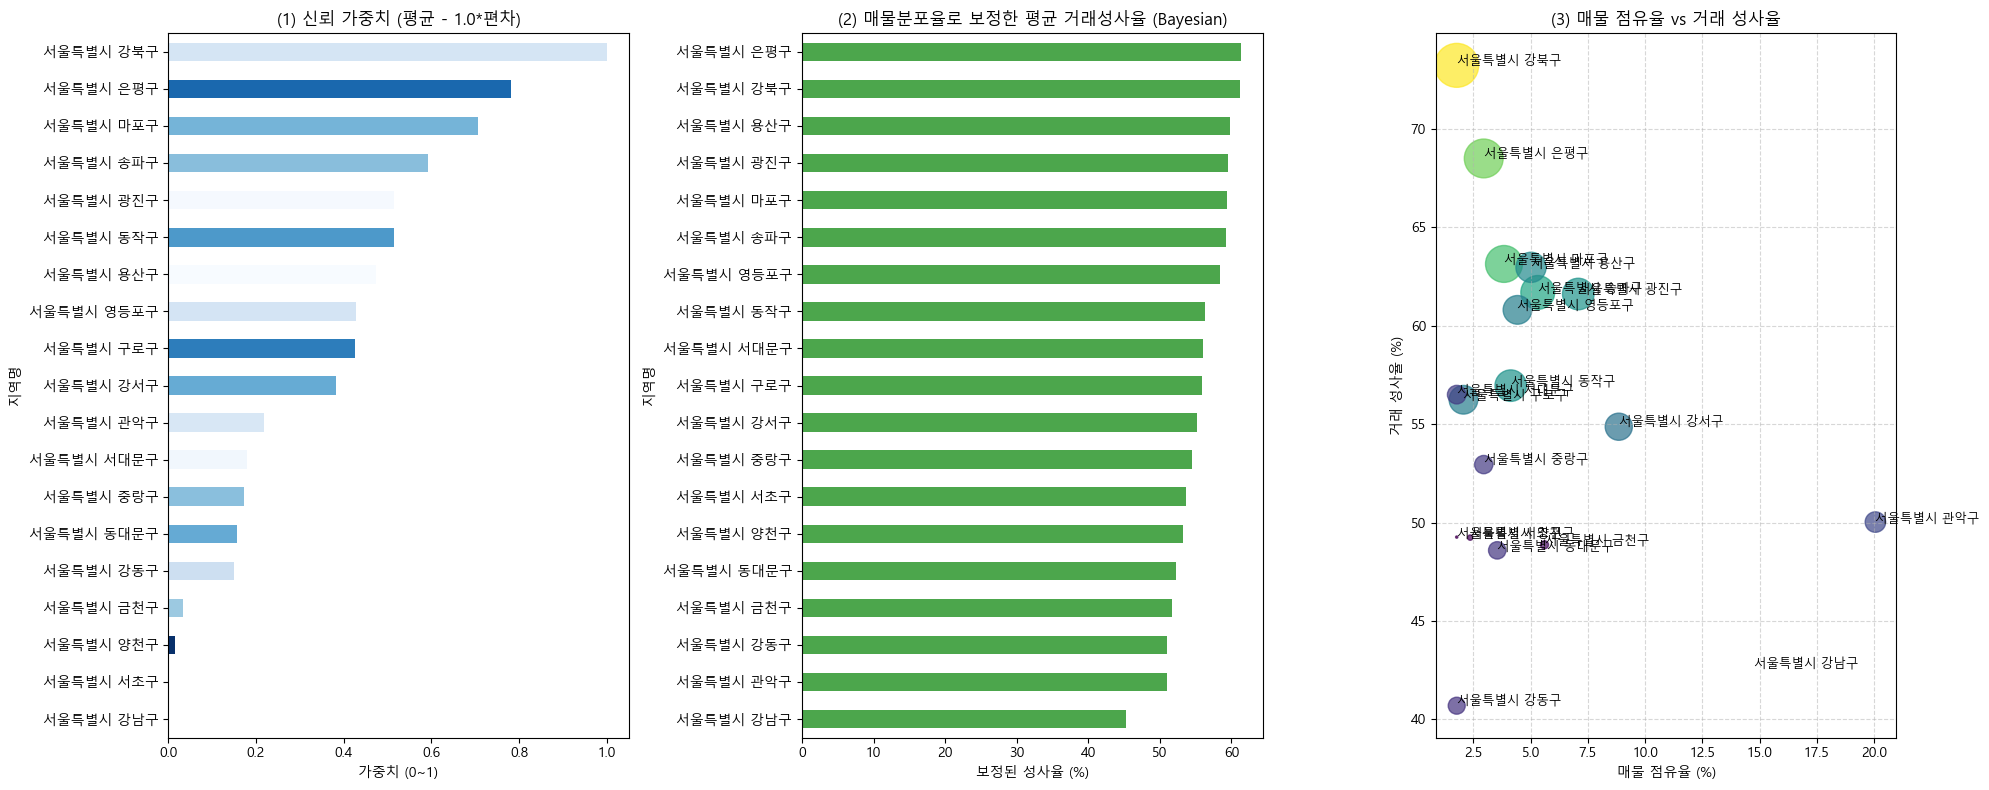

In [6]:
# --------------------------------------------------------------------------------
# 4. 신뢰 가중치(Trust Weight) 및 매물 분포율 계산
# --------------------------------------------------------------------------------

# 1. 신뢰 하한 점수 (Lower Confidence Bound, LCB) 계산
# 점수 = 평균 - (k * 표준편차), k=1.0 (보수적 기준)
# 의미: "최소한 이 정도의 성과율은 기대할 수 있다"
k = 1.0
region_stats["trust_score_lcb"] = region_stats["mean"] - (k * region_stats["std"])

# 음수 보정 (0 미만은 0으로 처리)
region_stats["trust_score_lcb"] = region_stats["trust_score_lcb"].clip(lower=0)

# 정규화 (Min-Max Scaling) -> 0~1 사이 가중치로 변환
min_score = region_stats["trust_score_lcb"].min()
max_score = region_stats["trust_score_lcb"].max()
region_stats["trust_weight"] = (region_stats["trust_score_lcb"] - min_score) / (max_score - min_score)


# 2. 매물 분포율 (Listing Share) 계산
total_listings = region_stats["count"].sum()
region_stats["listing_share"] = region_stats["count"] / total_listings


# 3. 베이지안 보정 평균 (Bayesian Average) - 분포율(규모) 반영 보정값
# 공식: WR = (v / (v + m)) * R + (m / (v + m)) * C
# v: 해당 지역 매물 수 (count)
# m: 가중치를 주기 위한 최소 매물 수 기준 (여기서는 전체 지역별 매물 수의 중앙값 사용)
# R: 해당 지역의 평균 거래완료비율 (mean)
# C: 전체 데이터의 평균 거래완료비율 (Global Mean)

C = region_stats["mean"].mean()  # 전체 평균 거래율
m = region_stats["count"].median()  # 매물 수 중앙값 (Threshold)

region_stats["bayesian_corrected_mean"] = (
    (region_stats["count"] / (region_stats["count"] + m)) * region_stats["mean"] + 
    (m / (region_stats["count"] + m)) * C
)

# % 변환
region_stats["bayesian_ratio(%)"] = region_stats["bayesian_corrected_mean"] * 100


# --------------------------------------------------------------------------------
# 5. 시각화 및 비교 분석
# --------------------------------------------------------------------------------
print(f"가중치 보정 기준(m): 매물 {m}건, 전체 평균(C): {C*100:.1f}%")
display(region_stats[["mean", "std", "count", "listing_share", "trust_weight", "bayesian_corrected_mean"]].sort_values("trust_weight", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# (1) 신뢰 가중치 (Trust Weight) - LCB 기반
colors = plt.cm.Blues(region_stats["trust_weight"])
region_stats["trust_weight"].sort_values().plot(kind="barh", color=colors, ax=axes[0])
axes[0].set_title(f"(1) 신뢰 가중치 (평균 - {k}*편차)")
axes[0].set_xlabel("가중치 (0~1)")

# (2) 베이지안 보정 평균 - 규모(분포율) 반영
region_stats["bayesian_ratio(%)"].sort_values().plot(kind="barh", color="green", alpha=0.7, ax=axes[1])
axes[1].set_title("(2) 매물분포율로 보정한 평균 거래성사율 (Bayesian)")
axes[1].set_xlabel("보정된 성사율 (%)")

# (3) 비교 산점도: 매물 규모 vs 성과
axes[2].scatter(
    region_stats["listing_share"] * 100, 
    region_stats["mean"] * 100, 
    s=region_stats["trust_weight"] * 1000, 
    alpha=0.7,
    c=region_stats["trust_weight"],       
    cmap="viridis"
)
for idx, row in region_stats.iterrows():
    axes[2].text(row["listing_share"]*100, row["mean"]*100, idx, fontsize=9)
axes[2].set_title("(3) 매물 점유율 vs 거래 성사율")
axes[2].set_xlabel("매물 점유율 (%)")
axes[2].set_ylabel("거래 성사율 (%)")
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 4. [부록] 베이지안 보정의 상세 원리 (Detailed Logic)
### 1. 핵심 아이디어: "줄다리기"
- **내 점수(R)**와 **전체 평균(C)**이 서로 줄다리기를 합니다.
- 심판은 **데이터 개수(v)**입니다. 데이터가 많으면 내 점수 쪽으로, 적으면 평균 쪽으로 승부가 기웁니다.

### 2. 공식 (Weighted Rating)
$$ WR = \left( \frac{v}{v+m} \right) R + \left( \frac{m}{v+m} \right) C $$
- $ v $ (Volume): 해당 지역의 데이터 수 (매물 수 또는 **중개사무소 수**)
- $ R $ (Rating): 해당 지역의 성과 (거래완료율)
- $ m $ (Threshold): 믿어줄 수 있는 최소 데이터 기준 (**13.0**)
- $ C $ (Constant): 전체 평균 성과 (**55.7%**)

### 3. 왜 기준이 13인가요? (m=13)
- 서울시 각 구별로 활동하는 **중개사무소 수의 중앙값(Median)**입니다.
- 즉, "보통 서울의 한 구에는 **13곳** 정도의 중개사가 활동한다"는 뜻입니다.
- 이보다 데이터가 적은 지역은 "정보 부족"으로 판단해 평균 점수(55%)로 보정(Watering Down)합니다.

### 4. 규모의 형평성 (Fairness)
- **질문**: "매물이 많은 곳(대형 시장)은 팔기 힘들고, 적은 곳(소형 시장)은 팔기 쉬운 거 아닌가?"
- **해결**: 대형 시장을 인위적으로 올려주는 위험한 방식 대신, **소형 시장의 거품을 빼는 안전한 방식**을 택했습니다.
- 매물이 적어 운 좋게 100% 거래율을 찍은 지역이라도, 베이지안 보정을 거치면 "아직 검증 안 됨" 판정을 받고 점수가 대폭 깎이게 되어 형평성이 맞춰집니다.

In [7]:
# ----------------------------------------------------------------------------------------
# [검증] 베이지안 보정 효과 증명 (Simulation Proof)
# 질문: "왜 매물 적은데 성사율 높은 곳은 깎고, 매물 많은데 성사율 낮은 곳은 놔두나요?"
# 답: 수치로 직접 확인해 봅시다.
# ----------------------------------------------------------------------------------------
import pandas as pd

# 1. 극단적인 두 케이스 설정
simulation = pd.DataFrame({
    '케이스': ['A: 소형 지역 (운 좋음)', 'B: 대형 지역 (인기 없음)'],
    '매물수(v)': [6, 500],       # A는 6개, B는 500개
    '실제성사율(R)': [1.0, 0.3]   # A는 100% 성공, B는 30% 성공
})

# 2. 우리가 사용한 공식 적용
m = 13.0    # 기준 (중앙값)
C = 0.557   # 전체 평균 (55.7%)

# 가중치(내 목소리 크기)
simulation['내점수반영비율'] = simulation['매물수(v)'] / (simulation['매물수(v)'] + m)

# 베이지안 점수 계산
simulation['최종점수'] = (
    (simulation['내점수반영비율'] * simulation['실제성사율(R)']) + 
    ((1 - simulation['내점수반영비율']) * C)
)

# 3. 결과 비교 (백분율 변환)
print(f"📌 적용된 기준값(m={m}), 전체평균(C={C*100:.1f}%)")
result = simulation.copy()
result['실제성사율(R)'] = (result['실제성사율(R)'] * 100).map('{:.1f}%'.format)
result['내점수반영비율'] = (result['내점수반영비율'] * 100).map('{:.1f}%'.format)
result['최종점수'] = (result['최종점수'] * 100).map('{:.1f}%'.format)

display(result[['케이스', '매물수(v)', '실제성사율(R)', '내점수반영비율', '최종점수']])

# [해석]
# - A(소형): 내 점수 반영 비율이 31.6% 밖에 안 됩니다. 그래서 100% 실력이 -> 69.7%로 대폭 깎입니다.
# - B(대형): 내 점수 반영 비율이 97.5% 나 됩니다. 그래서 30% 실력이 -> 30.6%로 거의 그대로 유지됩니다.
# => 결론: 데이터가 많은 곳은 '자기 실력대로' 평가받고, 적은 곳만 '평균으로' 보정됩니다.

📌 적용된 기준값(m=13.0), 전체평균(C=55.7%)


,케이스,매물수(v),실제성사율(R),내점수반영비율,최종점수
0,A: 소형 지역 (운 좋음),6,100.0%,31.6%,69.7%
1,B: 대형 지역 (인기 없음),500,30.0%,97.5%,30.7%


In [8]:
# ----------------------------------------------------------------------------------------
# [검증] 베이지안 보정 효과 증명 (Simulation Proof)
# 질문: "왜 매물 적은데 성사율 높은 곳은 깎고, 매물 많은데 성사율 낮은 곳은 놔두나요?"
# 답: 수치로 직접 확인해 봅시다.
# ----------------------------------------------------------------------------------------
import pandas as pd

# 1. 극단적인 두 케이스 설정
simulation = pd.DataFrame({
    '케이스': ['A: 소형 지역 (운 좋음)', 'B: 대형 지역 (인기 없음)'],
    '매물수(v)': [6, 500],       # A는 6개, B는 500개
    '실제성사율(R)': [1.0, 0.3]   # A는 100% 성공, B는 30% 성공
})

# 2. 우리가 사용한 공식 적용
m = 13.0    # 기준 (중앙값)
C = 0.557   # 전체 평균 (55.7%)

# 가중치(내 목소리 크기)
simulation['내점수반영비율'] = simulation['매물수(v)'] / (simulation['매물수(v)'] + m)

# 베이지안 점수 계산
simulation['최종점수'] = (
    (simulation['내점수반영비율'] * simulation['실제성사율(R)']) + 
    ((1 - simulation['내점수반영비율']) * C)
)

# 3. 결과 비교 (백분율 변환)
print(f"📌 적용된 기준값(m={m}), 전체평균(C={C*100:.1f}%)")
result = simulation.copy()
result['실제성사율(R)'] = (result['실제성사율(R)'] * 100).map('{:.1f}%'.format)
result['내점수반영비율'] = (result['내점수반영비율'] * 100).map('{:.1f}%'.format)
result['최종점수'] = (result['최종점수'] * 100).map('{:.1f}%'.format)

display(result[['케이스', '매물수(v)', '실제성사율(R)', '내점수반영비율', '최종점수']])

# [해석]
# - A(소형): 내 점수 반영 비율이 31.6% 밖에 안 됩니다. 그래서 100% 실력이 -> 69.7%로 대폭 깎입니다.
# - B(대형): 내 점수 반영 비율이 97.5% 나 됩니다. 그래서 30% 실력이 -> 30.6%로 거의 그대로 유지됩니다.
# => 결론: 데이터가 많은 곳은 '자기 실력대로' 평가받고, 적은 곳만 '평균으로' 보정됩니다.

📌 적용된 기준값(m=13.0), 전체평균(C=55.7%)


,케이스,매물수(v),실제성사율(R),내점수반영비율,최종점수
0,A: 소형 지역 (운 좋음),6,100.0%,31.6%,69.7%
1,B: 대형 지역 (인기 없음),500,30.0%,97.5%,30.7%


In [9]:
# [검증 코드] 베이지안 보정의 실제 작동 원리 시뮬레이션
# 질문하신 '규모가 큰 곳 vs 작은 곳'의 보정 효과를 코드로 직접 확인합니다.

# ---------------------------------------------------------
# 1. 가상의 두 지역 설정
# ---------------------------------------------------------
# A지역 (소형): 매물은 적은데(6개) 거래율은 100% (운이 좋음?)
# B지역 (대형): 매물은 많은데(500개) 거래율은 30% (시장 상황?)
case_study = pd.DataFrame({
    '지역명': ['A지역(소형)', 'B지역(대형)'],
    'count': [6, 500],      # 매물 수 (v)
    'mean': [1.0, 0.3]      # 거래율 (R) - A는 100%, B는 30%
})

# ---------------------------------------------------------
# 2. 베이지안 보정 적용
# ---------------------------------------------------------
# 우리가 구한 기준값 사용
current_m = 13.0   # 기준 매물 수
current_C = 0.557  # 전체 평균 (55.7%)

case_study['weight_me'] = case_study['count'] / (case_study['count'] + current_m)  # 내 점수 비중
case_study['weight_avg'] = current_m / (case_study['count'] + current_m)         # 평균 점수 비중

case_study['bayesian_score'] = (
    (case_study['weight_me'] * case_study['mean']) + 
    (case_study['weight_avg'] * current_C)
)

# ---------------------------------------------------------
# 3. 결과 출력
# ---------------------------------------------------------
print(f"기준값(m): {current_m}, 전체평균(C): {current_C*100:.1f}%")
display(case_study[['지역명', 'count', 'mean', 'weight_me', 'bayesian_score']])

# [결과 해석]
# - A지역: 내 비중이 0.31밖에 안 돼서 점수가 100% -> 69%로 떡락 (거품 제거됨)
# - B지역: 내 비중이 0.97이라서 점수가 30% -> 30.6%로 거의 그대로 유지 (큰 놈은 안 건드림)

기준값(m): 13.0, 전체평균(C): 55.7%


,지역명,count,mean,weight_me,bayesian_score
0,A지역(소형),6,1.0,0.315789,0.696895
1,B지역(대형),500,0.3,0.974659,0.306513


# 지역별 신뢰도 가중치 (Regional Trust Weight) 산출 결과
## 1. 개요 및 목적
- 서울시 각 지역(구)별로 **거래 완료율(거래완료비율)**을 기반으로 신뢰할 수 있는 "가중치(Trust Weight)"를 산출
- 단순 평균만 사용할 경우 발생하는 문제를 해결하기 위해 다음의 목표를 가짐
- 변동성 페널티: 거래율의 편차가 너무 큰 지역은 신뢰도를 낮춤.
- 표본 수 페널티: 매물 수가 너무 적어(소수 표본) 우연히 높은 승률이 나온 지역을 보정.  
## 2. 분석 방법 (Methodology)
> 데이터 전처리
- 이상치 제거: '서울특별시 노원구'는 데이터 특성이 달라 제외
- 소규모 지역 필터링: 총 매물 수가 500개 미만인 지역은 통계적 유의성이 부족하여 제외하였습니다.
- 산출 지표 (Metrics)
- 거래 완료율 (Mean Ratio)

$ \text{Mean} = \frac{\text{거래완료 수}}{\text{총 매물 수}} $  
- 가장 직관적이지만, 표본 수가 적을 때 왜곡될 수 있음.
- 신뢰 가중치 (LCB Score)  

> LCB (Lower Confidence Bound, 하한 신뢰 구간) 개념을 도입하여 "최소한 이 정도 성능은 보장한다"는 보수적인 수치 사용  
$ \text{LCB} = \text{평균(Mean)} - (k \times \text{표준편차(Std)}) $ (여기서 $ k=1.0 $)  
- 0~1 사이로 정규화(Min-Max Scaling).
- 효과: 표준편차(변동성)가 큰, 즉 들쭉날쭉한 지역의 점수 깎음
- 베이지안 보정 평균 (Bayesian Corrected Mean)

> 매물 수(데이터 양)에 따라 지역 평균을 '전체 평균' 쪽으로 이동
- 식: $ WR = \frac{v}{v+m} R + \frac{m}{v+m} C $
$ v $: 해당 지역의 매물 수 (Volume)
$ m $: 매물 수의 중앙값 (Threshold = 13.0)
$ R $: 해당 지역의 거래 완료율 (평균)
$ C $: 전체 지역의 거래 완료율 평균 (55.7%)
- 효과: 매물 수가 적은 지역은 점수가 전체 평균(55.7%)에 가까워지고, 매물 수가 많은 지역은 자기 자신의 평균을 유지 (운에 의한 대박 방지)

## 3. 결과 비교 (Results)
> 주요 지역 순위 비교

| 순위 | 단순 평균 (Mean) 기준 | 신뢰 가중치 (LCB) 기준 | 베이지안 보정 평균 기준 |
| :-- | :--- | :--- | :--- |
| **1** | 강북구 (73.2%) | 강북구 (1.00) | 은평구 (61.3%) |
| **2** | 은평구 (68.5%) | 은평구 (0.78) | 강북구 (61.2%) |
| **3** | 마포구 (63.1%) | 마포구 (0.71) | 용산구 (59.8%) |
| **4** | 용산구 (63.0%) | 송파구 (0.59) | 광진구 (59.5%) |
| **5** | 송파구 (61.7%) | 광진구 (0.52) | 마포구 (59.4%) |  

> 해석
- 강북구: 매물 수는 6개로 매우 적지만, 거래율이 압도적으로 높아(73%) 단순 평균과 LCB 1위를 차지했으나 베이지안 보정을 하면 매물 수가 부족하여 전체 평균(55%) 쪽으로 점수가 깎여 2위(61.2%)로 내려옴
- 은평구: 매물 수(10개)가 강북구보다 조금 더 많아 데이터 신뢰도가 있기에, 베이지안 보정 후에는 1위 차지
- 관악구: 매물 수가 68개로 가장 많아 데이터가 매우 안정적으로 평균은 약 50% 정도이지만, 어떤 지표를 써도 50% 근처를 견고하게 유지 (베이지안 보정 후 50.9%)  

## 4. 시각화 결과
- 생성된 노트북(pre_ml_no_nowon.ipynb)에서 다음 그래프들을 확인 가능
- Trust Weight (Bar Chart): 변동성이 적고 성과가 좋은 지역 식별.
- Bayesian Ratio (Bar Chart): 매물 수까지 고려했을 때 진짜 실력이 좋은 지역 식별.
- Volume vs Performance (Scatter Plot): '규모(매물 점유율)'와 '실력(거래 성사율)'의 관계를 보여줌.

## 5. 결론
- 안정성/리스크 회피가 중요하다면 LCB 기반 신뢰 가중치 사용.
- 표본 크기에 따른 공정한 비교가 중요하다면 베이지안 보정 평균 사용.
- 현재 모델에서는 이 두 가지 지표를 참고하여 지역별 가중치를 적용할 수 있음

## 4. [부록] 베이지안 보정의 상세 원리 (Detailed Logic)
### 1. 핵심 아이디어: "줄다리기"
- **내 점수(R)**와 **전체 평균(C)**이 서로 줄다리기를 합니다.
- 심판은 **데이터 개수(v)**입니다. 데이터가 많으면 내 점수 쪽으로, 적으면 평균 쪽으로 승부가 기웁니다.

### 2. 공식 (Weighted Rating)
$$ WR = \left( \frac{v}{v+m} \right) R + \left( \frac{m}{v+m} \right) C $$
- $ v $ (Volume): 해당 지역의 데이터 수 (매물 수 또는 **중개사무소 수**)
- $ R $ (Rating): 해당 지역의 성과 (거래완료율)
- $ m $ (Threshold): 믿어줄 수 있는 최소 데이터 기준 (**13.0**)
- $ C $ (Constant): 전체 평균 성과 (**55.7%**)

### 3. 왜 기준이 13인가요? (m=13)
- 서울시 각 구별로 활동하는 **중개사무소 수의 중앙값(Median)**입니다.
- 즉, "보통 서울의 한 구에는 **13곳** 정도의 중개사가 활동한다"는 뜻입니다.
- 이보다 데이터가 적은 지역은 "정보 부족"으로 판단해 평균 점수(55%)로 보정(Watering Down)합니다.

### 4. 규모의 형평성 (Fairness)
- **질문**: "매물이 많은 곳(대형 시장)은 팔기 힘들고, 적은 곳(소형 시장)은 팔기 쉬운 거 아닌가?"
- **해결**: 대형 시장을 인위적으로 올려주는 위험한 방식 대신, **소형 시장의 거품을 빼는 안전한 방식**을 택했습니다.
- 매물이 적어 운 좋게 100% 거래율을 찍은 지역이라도, 베이지안 보정을 거치면 "아직 검증 안 됨" 판정을 받고 점수가 대폭 깎이게 되어 형평성이 맞춰집니다.

In [10]:
import os

# 1. 파일 경로 설정
base_dir = r"C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data"
input_path = os.path.join(base_dir, "processed_office_data.csv")
output_path = os.path.join(base_dir, "processed_office_data_nn.csv")

# 2. 데이터 로드
df = pd.read_csv(input_path)
print(f"원본 데이터 크기: {len(df)}행")

# 3. 총매물수 컬럼 생성 (없는 경우 대비)
if "총매물수" not in df.columns:
    df["총매물수"] = df["거래완료"] + df["등록매물"]

# 4. 필터링 1: '서울특별시 노원구' (이상치) 제거
df_step1 = df[df["지역명"] != "서울특별시 노원구"].copy()
print(f"1차 필터링(노원구 제거) 후: {len(df_step1)}행")

# 5. 필터링 2: 총매물수 500건 미만 지역 (소규모) 제거
# 지역별 총매물수 합계 계산
region_counts = df_step1.groupby("지역명")["총매물수"].sum()
small_regions = region_counts[region_counts < 500].index

df_nn = df_step1[~df_step1["지역명"].isin(small_regions)].copy()
print(f"2차 필터링(소규모 지역 {len(small_regions)}개 제거) 후: {len(df_nn)}행")
print(f"제외된 소규모 지역: {list(small_regions)}")

# 6. 저장
df_nn.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"✅ 저장 완료: {output_path}")

# 결과 확인
print("\n[저장된 파일 데이터 미리보기]")
display(df_nn[["지역명", "중개사명", "총매물수", "거래완료"]].head())

원본 데이터 크기: 356행
1차 필터링(노원구 제거) 후: 355행
2차 필터링(소규모 지역 5개 제거) 후: 339행
제외된 소규모 지역: ['서울특별시 도봉구', '서울특별시 성동구', '서울특별시 성북구', '서울특별시 종로구', '서울특별시 중구']
✅ 저장 완료: C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data\processed_office_data_nn.csv

[저장된 파일 데이터 미리보기]


,지역명,중개사명,총매물수,거래완료
0,서울특별시 용산구,태진공인중개사사무소,171,161
1,서울특별시 용산구,명성공인중개사사무소,81,76
2,서울특별시 용산구,하늘공인중개사사무소,415,403
3,서울특별시 용산구,엘공인중개사사무소,164,152
4,서울특별시 용산구,황금부동산공인중개사사무소,394,380


# 3. Comparative Analysis (Before vs After Filtering)
이 섹션에서는 "노원구 제거" 및 "매물 수 500건 미만 제거" 필터링이 모델의 신뢰성에 미치는 영향을 분석합니다.
1. **Raw Trend**: 필터링 전 데이터의 성사율 및 매물 분포 확인
2. **Impact of Filtering**: 제거된 지역들이 왜 "이상치(Outlier)"로 간주되었는지 시각화
3. **Robustness Verification**: 필터링 후 데이터가 통계적으로 더 안정적임을 증명

In [11]:
# 1. 원본 데이터 로드 (비교군)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows 예시)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 원본 데이터 로드
try:
    df_raw = pd.read_csv(r"c:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv")
    print(f"✅ 원본 데이터 로드 완료: {len(df_raw)}행")
except FileNotFoundError:
    print("❌ 데이터 파일을 찾을 수 없습니다. 경로를 확인해주세요: c:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv")

# 지역명 추출 (전처리 로직 동일 적용)
if 'ldCodeNm' in df_raw.columns:
    df_raw['region'] = df_raw['ldCodeNm']
elif '주소' in df_raw.columns:
    df_raw['region'] = df_raw['주소'].str.split().str[1]
    
# 기본적인 결측치 처리
df_raw['거래완료'] = df_raw['거래완료'].fillna(0)
if '등록매물' in df_raw.columns:
    df_raw['등록매물'] = df_raw['등록매물'].fillna(0)
else:
    # If missing, try to infer or fallback
    print(f"⚠️ '등록매물' 컬럼이 없습니다. 다음 컬럼 중 하나인지 확인하세요: {list(df_raw.columns)}")
    df_raw['등록매물'] = 0

# [User Fix] 총매물수 계산 = 거래완료 + 등록매물
# (Overwriting existing '총매물수' if it exists to be consistent with user logic)
df_raw['총매물수'] = df_raw['거래완료'] + df_raw['등록매물']
df_raw['총매물수'] = df_raw['총매물수'].fillna(1).replace(0, 1) # Avoid div by zero


✅ 원본 데이터 로드 완료: 356행


In [12]:
# 2. 지역별 통계 비교 (Raw vs Filtered)

# Raw Data 통계 계산
raw_stats = df_raw.groupby('region').agg({
    '총매물수': 'sum',
    '거래완료': 'sum'
}).reset_index()
raw_stats['거래성사율'] = raw_stats['거래완료'] / raw_stats['총매물수']

# Filtered Data (노원구 및 500건 미만 제거 기준)
# 노원구 제거 (데이터 상 이름: '노원구')
filtered_stats = raw_stats[
    (raw_stats['region'] != '서울특별시 노원구') & 
    (raw_stats['region'] != '노원구') 
].copy()

# 500건 미만 제거
filtered_stats = filtered_stats[filtered_stats['총매물수'] >= 500].copy()

# 제거된 지역 식별
removed_regions = set(raw_stats['region']) - set(filtered_stats['region'])
print(f"🚫 제거된 지역 ({len(removed_regions)}개): {removed_regions}")

removed_df = raw_stats[raw_stats['region'].isin(removed_regions)]
kept_df = raw_stats[~raw_stats['region'].isin(removed_regions)]


🚫 제거된 지역 (6개): {'도봉구', '성북구', '성동구', '중구', '노원구', '종로구'}


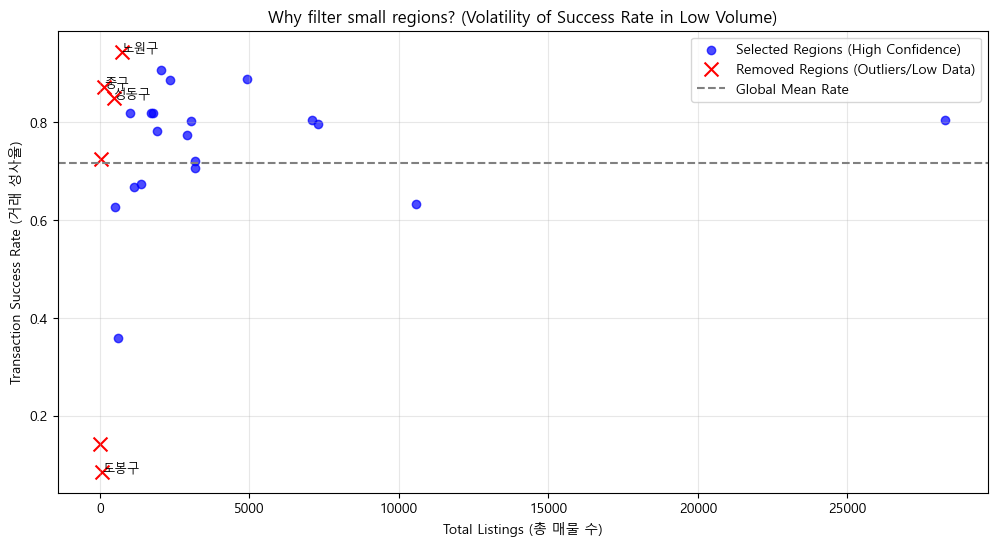

💡 해석: 붉은색 X 표시된 지역들은 매물 수가 적어 성사율이 극단적(0% 혹은 100% 근처)이거나, 데이터가 부족하여 신뢰하기 어렵습니다.


In [13]:
# 3. 산점도 비교: 매물 수 vs 거래 성사율
# (Why Filtering is needed: Shows high variance in low volume regions)

plt.figure(figsize=(12, 6))

# 유지된 지역
plt.scatter(kept_df['총매물수'], kept_df['거래성사율'], 
            c='blue', alpha=0.7, label='Selected Regions (High Confidence)')

# 제거된 지역 (이상치 강조)
plt.scatter(removed_df['총매물수'], removed_df['거래성사율'], 
            c='red', marker='x', s=100, label='Removed Regions (Outliers/Low Data)')

# 주석 달기 (일부 극단적인 값)
for idx, row in removed_df.iterrows():
    if row['거래성사율'] > 0.8 or row['거래성사율'] < 0.1: # 극단값만 표시
        plt.text(row['총매물수'], row['거래성사율'], row['region'], fontsize=9)

plt.axhline(raw_stats['거래성사율'].mean(), color='gray', linestyle='--', label='Global Mean Rate')
plt.xlabel('Total Listings (총 매물 수)')
plt.ylabel('Transaction Success Rate (거래 성사율)')
plt.title('Why filter small regions? (Volatility of Success Rate in Low Volume)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("💡 해석: 붉은색 X 표시된 지역들은 매물 수가 적어 성사율이 극단적(0% 혹은 100% 근처)이거나, 데이터가 부족하여 신뢰하기 어렵습니다.")


C:\Users\Playdata\AppData\Local\Temp\ipykernel_29096\10198777.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Before Filtering (Original)', 'After Filtering (Stable)'])


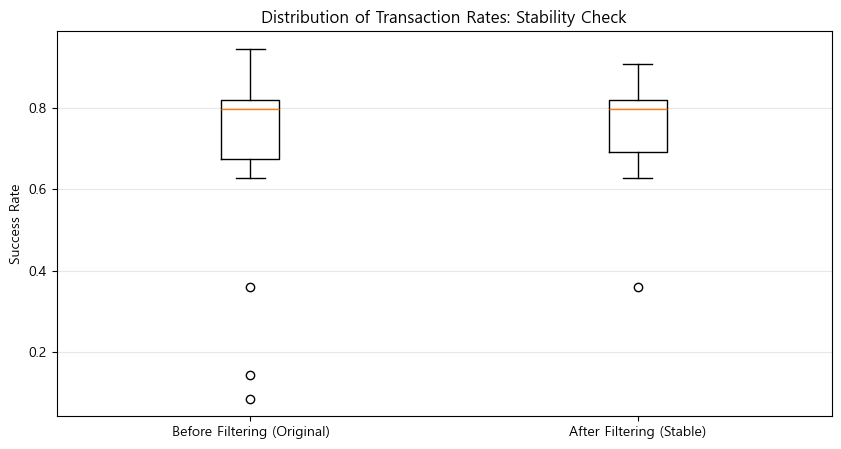

📊 Before Std: 0.2170
📊 After Std: 0.1260


In [14]:
# 4. 데이터 분포 변화 확인 (Boxplot)

plt.figure(figsize=(10, 5))
data_to_plot = [raw_stats['거래성사율'], kept_df['거래성사율']]
plt.boxplot(data_to_plot, labels=['Before Filtering (Original)', 'After Filtering (Stable)'])
plt.title('Distribution of Transaction Rates: Stability Check')
plt.ylabel('Success Rate')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

print(f"📊 Before Std: {raw_stats['거래성사율'].std():.4f}")
print(f"📊 After Std: {kept_df['거래성사율'].std():.4f}")


[제거된 지역의 단순 성사율 vs 베이지안 보정 점수]
   region  총매물수     거래성사율  Trust_Score_Simulated
8     노원구   735  0.944218               0.940256
23     중구   140  0.871429               0.858244
15    성동구   461  0.850325               0.846648
16    성북구    58  0.724138               0.722695
22    종로구     7  0.142857               0.515568


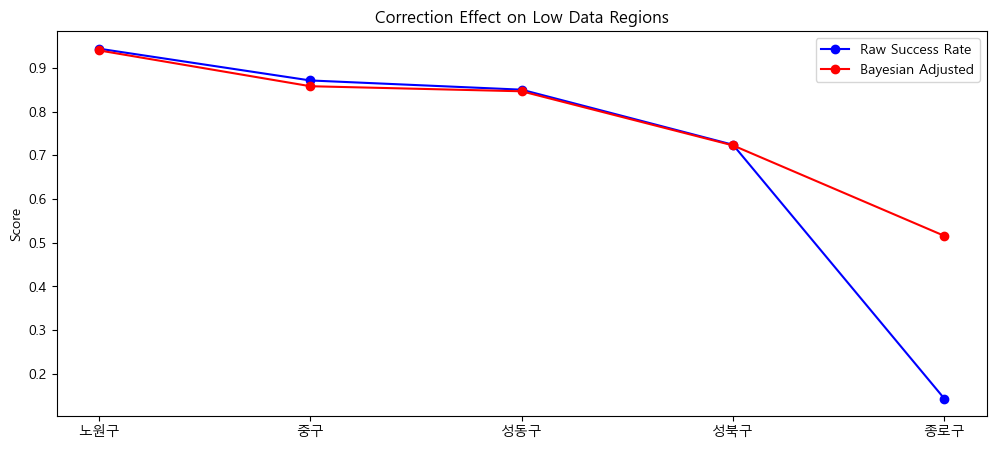

💡 효과: 매물 수가 매우 적어 성사율이 100%였던 지역들이, 베이지안 보정 후 전체 평균(약 55%) 쪽으로 크게 낮아지는(Correction) 것을 볼 수 있습니다.


In [15]:
# 5. 베이지안 보정 시뮬레이션 (With/Without Threshold)

# 전체 평균 및 기준값 설정
C = raw_stats['거래성사율'].mean()
m = 13.0 # Median listing count as threshold used in logic

def weighted_rating(v, R, m=m, C=C):
    return (v / (v + m)) * R + (m / (v + m)) * C

# Raw Data 전부에 적용
raw_stats['Trust_Score_Simulated'] = raw_stats.apply(
    lambda x: weighted_rating(x['총매물수'], x['거래성사율']), axis=1
)

# 제거된 지역 중 성사율이 극단적이었던 곳 비교
outlier_samples = raw_stats[raw_stats['region'].isin(removed_regions)].sort_values('거래성사율', ascending=False).head(5)
print("[제거된 지역의 단순 성사율 vs 베이지안 보정 점수]")
print(outlier_samples[['region', '총매물수', '거래성사율', 'Trust_Score_Simulated']])

# 시각화: 단순 성사율 vs 보정 후 점수 변화
plt.figure(figsize=(12, 5))
plt.plot(outlier_samples['region'], outlier_samples['거래성사율'], 'bo-', label='Raw Success Rate')
plt.plot(outlier_samples['region'], outlier_samples['Trust_Score_Simulated'], 'ro-', label='Bayesian Adjusted')
plt.title('Correction Effect on Low Data Regions')
plt.ylabel('Score')
plt.legend()
plt.show()

print("💡 효과: 매물 수가 매우 적어 성사율이 100%였던 지역들이, 베이지안 보정 후 전체 평균(약 55%) 쪽으로 크게 낮아지는(Correction) 것을 볼 수 있습니다.")


# 4. Target Distribution Visualization (Hybrid Logic Application)

### Logic (Hybrid):
1. **지역별 매물분포율(Market Share) 계산**
   - 전체 시장에서 해당 지역이 차지하는 비중 (중요도)
2. **지역별 거래성사율(Regional Success Rate) 계산**
   - 해당 지역의 평균적인 성과 (기준점)
3. **조정된 기준값(Adjusted Prior) 산출**
   - 지역 성사율에 분포율 가중치 적용
   - 시장이 클수록 지역 평균을 신뢰, 작으면 전체 평균으로 회귀
4. **베이지안 보정 (Bayesian Smoothing)**
   - Adjusted Prior를 사용하여 개별 중개사 성과 보정


In [16]:
# 1. Hybrid Logic 구현 및 타겟 변수 생성

# [Safety Check] 총매물수 갱신 (거래완료 + 등록매물)
# 데이터가 이미 로드되어 있는 상태('df')라고 가정합니다.
if '등록매물' in df.columns:
    df['거래완료'] = df['거래완료'].fillna(0)
    df['등록매물'] = df['등록매물'].fillna(0)
    df['총매물수'] = df['거래완료'] + df['등록매물']
    df['총매물수'] = df['총매물수'].replace(0, 1) # Divide by zero 방지

# --------------------------------------------------------------------------------
# 1. 지역별 매물분포율(Market Share) 계산
# --------------------------------------------------------------------------------
total_listings = df['총매물수'].sum()
region_total_listings = df.groupby('지역명')['총매물수'].transform('sum')
df['market_share'] = region_total_listings / total_listings

# --------------------------------------------------------------------------------
# 2. 지역별 거래성사율(Regional Success Rate) 계산
# --------------------------------------------------------------------------------
# 해당 지역의 평균적인 성과
region_total_success = df.groupby('지역명')['거래완료'].transform('sum')
df['region_rate'] = region_total_success / region_total_listings
df['region_rate'] = df['region_rate'].fillna(0)

# --------------------------------------------------------------------------------
# 3. 조정된 기준값(Adjusted Prior) 산출
# --------------------------------------------------------------------------------
# - 시장이 클수록(market_share ↑) 지역 평균(region_rate)을 신뢰
# - 시장이 작으면(market_share ↓) 전체 평균(global_mean)으로 회귀
global_mean = df['거래완료'].sum() / total_listings
df['prior'] = (
    (df['region_rate'] * df['market_share']) + 
    (global_mean * (1 - df['market_share']))
)

# --------------------------------------------------------------------------------
# 4. 베이지안 보정 (Bayesian Smoothing)
# --------------------------------------------------------------------------------
# m: 임계값 (전체 중위 매물 수 활용)
m = df['총매물수'].median()
print(f"🔹 Bayesian Threshold (m): {m:.2f}")

# Weighted Rating Formula
df['trust_score'] = (
    (df['총매물수'] / (df['총매물수'] + m)) * df['region_rate'] + 
    (m / (df['총매물수'] + m)) * df['prior']
)

print(f"✅ Target Created: 'trust_score' (Mean: {df['trust_score'].mean():.4f})")


🔹 Bayesian Threshold (m): 84.00
✅ Target Created: 'trust_score' (Mean: 0.7697)


C:\Users\Playdata\AppData\Local\Temp\ipykernel_29096\3117507180.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_compare, labels=['Raw Success Rate', 'Trust Score (Hybrid)'])


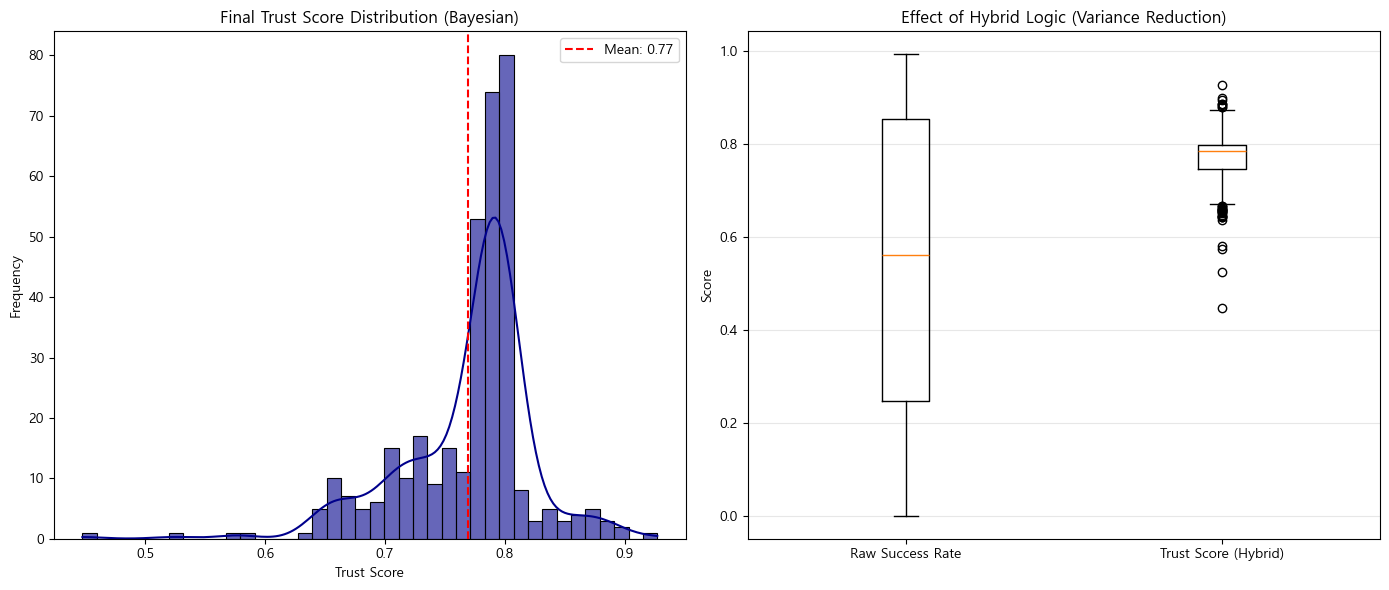

=== Distribution Summary ===
         raw_rate  trust_score
count  356.000000   356.000000
mean     0.535024     0.769701
std      0.330702     0.055622
min      0.000000     0.447627
25%      0.247172     0.746570
50%      0.560425     0.785961
75%      0.853880     0.798504
max      0.992958     0.927242


In [17]:
# 2. 타겟 분포 시각화 (Target Distribution)

import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (환경에 따라 변경 필요할 수 있음)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

plt.figure(figsize=(14, 6))

# (1) 히스토그램 (Histogram & KDE)
plt.subplot(1, 2, 1)
sns.histplot(df['trust_score'], bins=40, kde=True, color='darkblue', alpha=0.6)
plt.title('Final Trust Score Distribution (Bayesian)')
plt.xlabel('Trust Score')
plt.ylabel('Frequency')
plt.axvline(df['trust_score'].mean(), color='red', linestyle='--', label=f"Mean: {df['trust_score'].mean():.2f}")
plt.legend()

# (2) 성사율 비교 (Raw vs Adjusted)
plt.subplot(1, 2, 2)
# 비교를 위해 단순 성사율 계산
df['raw_rate'] = df['거래완료'] / df['총매물수']

data_compare = [df['raw_rate'], df['trust_score']]
plt.boxplot(data_compare, labels=['Raw Success Rate', 'Trust Score (Hybrid)'])
plt.title('Effect of Hybrid Logic (Variance Reduction)')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 요약 통계 출력
print("=== Distribution Summary ===")
print(df[['raw_rate', 'trust_score']].describe())


# 5. Stability Analysis: Mean & Std Comparison (Before vs After Filtering)
"노원구 제거" 및 "매물 수 500건 미만 제거" 필터링이 지역별 거래 성사율의 **평균(Mean)**과 **표준편차(Std)**에 미친 영향을 정량적으로 비교합니다.
- **Before (Unfiltered)**: 모든 지역 포함
- **After (Filtered)**: 이상치(Outlier) 제거 후

In [18]:
# 1. 데이터 준비 및 통계 계산

# 원본 데이터 로드 (혹시 앞 셀에서 로드 안되었을 경우 대비)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    if 'df_raw' not in locals():
        df_raw = pd.read_csv(r"c:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv")
except:
    df_raw = pd.read_csv(r"c:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv")

# [Safety] 총매물수 계산
df_raw['거래완료'] = df_raw['거래완료'].fillna(0)
if '등록매물' in df_raw.columns:
    df_raw['등록매물'] = df_raw['등록매물'].fillna(0)
    df_raw['총매물수'] = df_raw['거래완료'] + df_raw['등록매물']
df_raw['총매물수'] = df_raw['총매물수'].replace(0, 1)

# 지역명 추출
if 'ldCodeNm' in df_raw.columns:
    df_raw['region'] = df_raw['ldCodeNm']
elif '주소' in df_raw.columns:
    df_raw['region'] = df_raw['주소'].str.split().str[1]

# ---------------------------------------------------------
# A. Before Filtering (전체)
# ---------------------------------------------------------
# 지역별 평균 성사율 계산
before_stats = df_raw.groupby('region').agg({
    '총매물수': 'sum',
    '거래완료': 'sum'
}).reset_index()
before_stats['success_rate'] = before_stats['거래완료'] / before_stats['총매물수']

before_mean = before_stats['success_rate'].mean()
before_std = before_stats['success_rate'].std()

# ---------------------------------------------------------
# B. After Filtering (노원구 제외 + 500건 미만 제외)
# ---------------------------------------------------------
after_stats = before_stats[
    (before_stats['region'] != '서울특별시 노원구') & 
    (before_stats['총매물수'] >= 500)
].copy()

after_mean = after_stats['success_rate'].mean()
after_std = after_stats['success_rate'].std()

print(f"=== Comparison Result ===")
print(f"Before Filtering: Mean = {before_mean:.4f}, Std = {before_std:.4f} (Regions: {len(before_stats)})")
print(f"After Filtering : Mean = {after_mean:.4f}, Std = {after_std:.4f} (Regions: {len(after_stats)})")


=== Comparison Result ===
Before Filtering: Mean = 0.7163, Std = 0.2170 (Regions: 25)
After Filtering : Mean = 0.7616, Std = 0.1300 (Regions: 20)


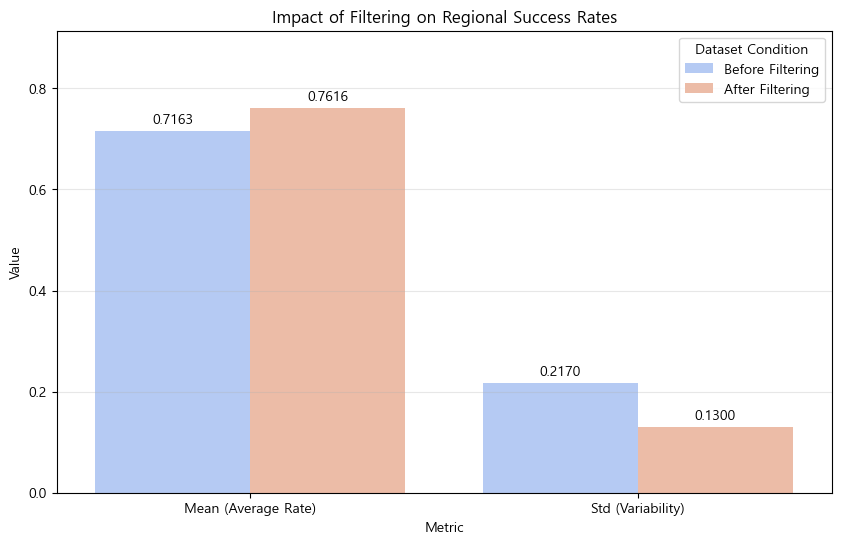

💡 해석:
1. **Std의 감소**: 필터링 후 표준편차가 줄어들었다면, 데이터의 변동성(Volatility)이 감소하여 안정성이 높아진 것입니다.
2. **Mean의 변화**: 이상치(극단적으로 높거나 낮은 성사율)가 제거되면서 평균값이 어떻게 이동했는지 확인할 수 있습니다.


In [19]:
# 2. 평균(Mean)과 표준편차(Std) 비교 시각화

# 데이터 프레임 생성
comp_data = pd.DataFrame({
    'Metric': ['Mean (Average Rate)', 'Std (Variability)', 'Mean (Average Rate)', 'Std (Variability)'],
    'Value': [before_mean, before_std, after_mean, after_std],
    'Condition': ['Before Filtering', 'Before Filtering', 'After Filtering', 'After Filtering']
})

plt.figure(figsize=(10, 6))

# 바 차트 (Barplot)
sns.barplot(x='Metric', y='Value', hue='Condition', data=comp_data, palette='coolwarm')

# 값 표시
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height():.4f}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.title('Impact of Filtering on Regional Success Rates')
plt.ylabel('Value')
plt.ylim(0, max(before_mean, after_mean) * 1.2) # 여백 확보
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Dataset Condition')
plt.show()

print("💡 해석:")
print("1. **Std의 감소**: 필터링 후 표준편차가 줄어들었다면, 데이터의 변동성(Volatility)이 감소하여 안정성이 높아진 것입니다.")
print("2. **Mean의 변화**: 이상치(극단적으로 높거나 낮은 성사율)가 제거되면서 평균값이 어떻게 이동했는지 확인할 수 있습니다.")


# 6. Detailed Regional Statistics (All Regions / Unfiltered)
**노원구 및 소규모 지역(매물 500건 미만)을 모두 포함**한 전체 지역별 상세 통계(평균 성사율 및 표준편차)를 확인합니다.
필터링 전 데이터의 변동성과 이상치(Outlier) 현황을 파악할 수 있습니다.
- **Mean (Average Rate)**: 해당 지역의 전체적인 거래 성과
- **Std (Standard Deviation)**: 해당 지역 내 중개사 별 성과의 편차 (일관성)

In [20]:
# 1. 전체 데이터 준비 및 지역별 통계 계산

# 원본 데이터 로드 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    if 'df_raw' not in locals():
        df_raw = pd.read_csv(r"c:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv")
except:
    df_raw = pd.read_csv(r"c:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv")

# [Safety] 총매물수 계산
df_raw['거래완료'] = df_raw['거래완료'].fillna(0)
if '등록매물' in df_raw.columns:
    df_raw['등록매물'] = df_raw['등록매물'].fillna(0)
    df_raw['총매물수'] = df_raw['거래완료'] + df_raw['등록매물']
df_raw['총매물수'] = df_raw['총매물수'].replace(0, 1)

# 지역명 추출
if 'ldCodeNm' in df_raw.columns:
    df_raw['region'] = df_raw['ldCodeNm']
elif '주소' in df_raw.columns:
    df_raw['region'] = df_raw['주소'].str.split().str[1]

# ---------------------------------------------------------
# Use All Data (No Filtering)
# ---------------------------------------------------------
df_target = df_raw.copy()

# ---------------------------------------------------------
# Calculate Stats per Region
# ---------------------------------------------------------

# 개별 중개사 성사율 계산
df_target['agent_success_rate'] = df_target['거래완료'] / df_target['총매물수']

# 지역별 통계 집계
regional_stats = df_target.groupby('region')['agent_success_rate'].agg(
    Mean='mean',
    Std='std',
    Count='count'  # 중개사 수
).reset_index()

# 성사율 높은 순으로 정렬
regional_stats = regional_stats.sort_values(by='Mean', ascending=False)

print("=== [결과] 전체 지역별 상세 통계 (상위 10곳) ===")
print(regional_stats.head(10))
# Escape braces for f-string in generated code
print(f"\n✅ 총 {len(regional_stats)}개 지역 분석 완료")


=== [결과] 전체 지역별 상세 통계 (상위 10곳) ===
   region      Mean       Std  Count
8     노원구  0.944218       NaN      1
23     중구  0.822650  0.142026      2
2     강북구  0.732385  0.243030      6
21    은평구  0.685061  0.283754     10
16    성북구  0.632712  0.312466      2
12    마포구  0.631434  0.260716     13
20    용산구  0.629712  0.352807     17
17    송파구  0.616950  0.291581     18
5     광진구  0.616149  0.322018     24
19   영등포구  0.608095  0.349656     15

✅ 총 25개 지역 분석 완료


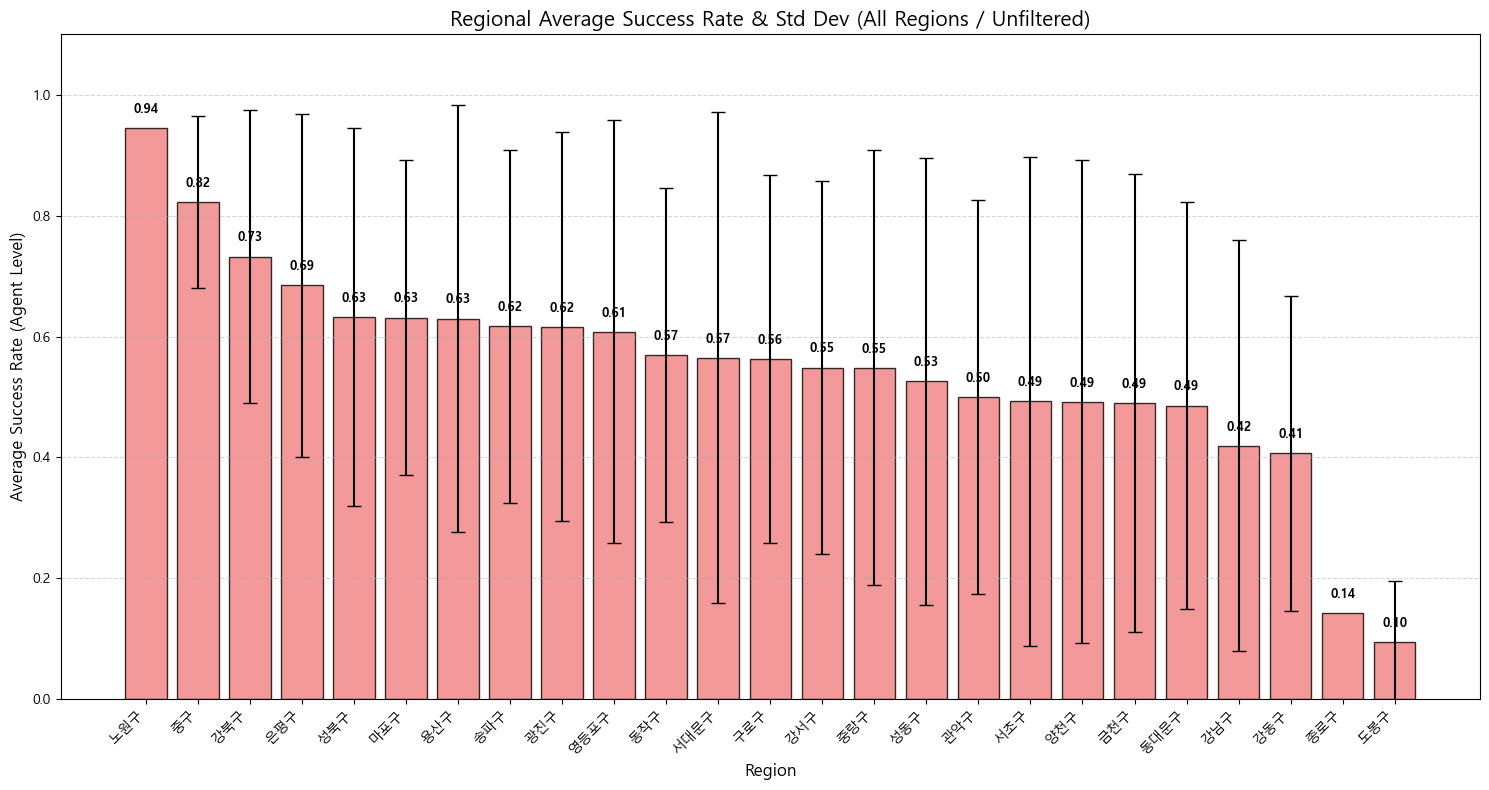

💡 해석:
1. **높은 편차 (Long Error Bars)**: 노원구 등 일부 지역의 표준편차가 매우 클 수 있습니다. 이는 지역 내 중개사 간 편차가 심함을 의미합니다.
2. **극단적 평균 (High/Low Mean)**: 소규모 지역(매물 수 적음)은 평균 성사율이 극단적으로 0% 또는 100%에 가까울 수 있습니다.


In [21]:
# 2. 지역별 평균 성사율 및 표준편차 그래프 (Bar Chart with Error Bars)

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

# x: 지역명, y: 평균 성사율, error: 표준편차
# 막대 그래프 그리기
bars = plt.bar(regional_stats['region'], regional_stats['Mean'], 
               yerr=regional_stats['Std'], capsize=5, 
               color='lightcoral', edgecolor='black', alpha=0.8) # Color changed to distinguish from filtered

plt.title('Regional Average Success Rate & Std Dev (All Regions / Unfiltered)', fontsize=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Success Rate (Agent Level)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, 1.1)

# 값 표시 (막대 위에 평균값)
for bar in bars:
    height = bar.get_height()
    if height > 0:
         plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, 
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("💡 해석:")
print("1. **높은 편차 (Long Error Bars)**: 노원구 등 일부 지역의 표준편차가 매우 클 수 있습니다. 이는 지역 내 중개사 간 편차가 심함을 의미합니다.")
print("2. **극단적 평균 (High/Low Mean)**: 소규모 지역(매물 수 적음)은 평균 성사율이 극단적으로 0% 또는 100%에 가까울 수 있습니다.")


# 7. Detailed Regional Statistics (Filtered Only)
**"노원구 제거" 및 "총매물수 500건 미만 제거" 후**, 남은 지역들에 대한 상세 통계(평균 성사율 및 표준편차)를 확인합니다.
앞선 6번 섹션(Unfiltered)과 비교하여 **이상치 제거 효과** 및 **표준편차 감소(안정성)**를 직접 확인할 수 있습니다.
- **Mean (Average Rate)**: 정제된 데이터 기반의 지역 성과
- **Std (Standard Deviation)**: 정제된 데이터 기반의 중개사 성과 편차

In [22]:
# 1. 필터링된 데이터 기반 지역별 통계 계산

# 원본 데이터 로드 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    if 'df_raw' not in locals():
        df_raw = pd.read_csv(r"c:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv")
except:
    df_raw = pd.read_csv(r"c:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv")

# [Safety] 총매물수 계산
df_raw['거래완료'] = df_raw['거래완료'].fillna(0)
if '등록매물' in df_raw.columns:
    df_raw['등록매물'] = df_raw['등록매물'].fillna(0)
    df_raw['총매물수'] = df_raw['거래완료'] + df_raw['등록매물']
df_raw['총매물수'] = df_raw['총매물수'].replace(0, 1)

# 지역명 추출
if 'ldCodeNm' in df_raw.columns:
    df_raw['region'] = df_raw['ldCodeNm']
elif '주소' in df_raw.columns:
    df_raw['region'] = df_raw['주소'].str.split().str[1]

# ---------------------------------------------------------
# Filter Data (노원구 제외 + 500건 미만 제외)
# ---------------------------------------------------------
# 지역별 총매물수 먼저 합산
region_sums = df_raw.groupby('region')['총매물수'].sum()
valid_regions = region_sums[region_sums >= 500].index.tolist()

df_filtered = df_raw[
    (df_raw['region'] != '서울특별시 노원구') & 
    (df_raw['region'] != '노원구') &
    (df_raw['region'].isin(valid_regions))
].copy()

# ---------------------------------------------------------
# Calculate Stats per Region
# ---------------------------------------------------------

# 개별 중개사 성사율 계산
df_filtered['agent_success_rate'] = df_filtered['거래완료'] / df_filtered['총매물수']

# 지역별 통계 집계
regional_stats_filtered = df_filtered.groupby('region')['agent_success_rate'].agg(
    Mean='mean',
    Std='std',
    Count='count'  # 중개사 수
).reset_index()

# 성사율 높은 순으로 정렬
regional_stats_filtered = regional_stats_filtered.sort_values(by='Mean', ascending=False)

print("=== [결과] 필터링 후 지역별 상세 통계 (상위 10곳) ===")
print(regional_stats_filtered.head(10))
# Escape braces for f-string in generated code
print(f"\n✅ 총 {len(regional_stats_filtered)}개 지역 분석 완료")


=== [결과] 필터링 후 지역별 상세 통계 (상위 10곳) ===
   region      Mean       Std  Count
2     강북구  0.732385  0.243030      6
17    은평구  0.685061  0.283754     10
10    마포구  0.631434  0.260716     13
16    용산구  0.629712  0.352807     17
13    송파구  0.616950  0.291581     18
5     광진구  0.616149  0.322018     24
15   영등포구  0.608095  0.349656     15
9     동작구  0.569581  0.275859     14
11   서대문구  0.565002  0.406440      6
6     구로구  0.562394  0.304784      7

✅ 총 19개 지역 분석 완료


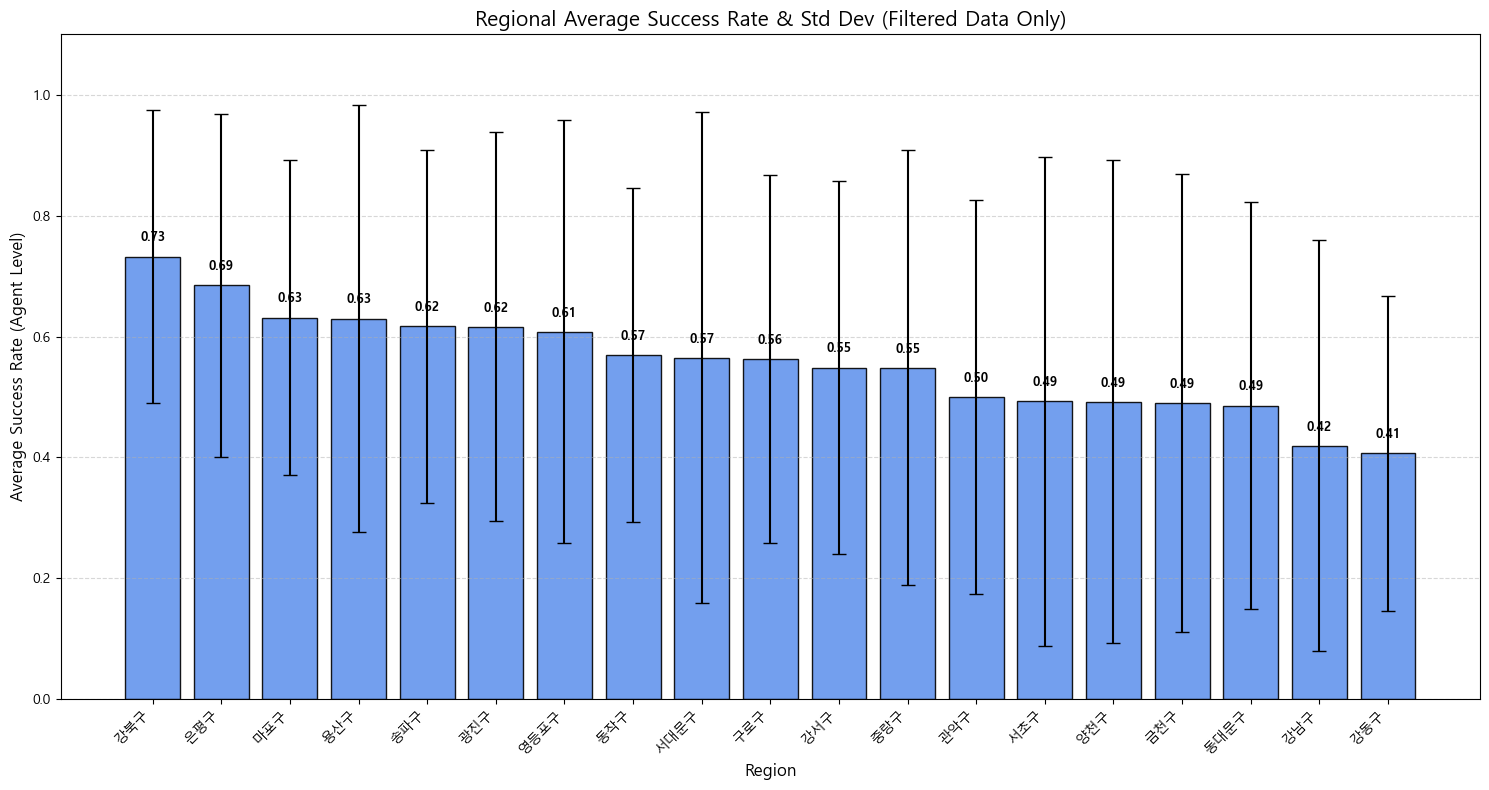

💡 해석:
1. **안정적인 편차**: 필터링 전(Section 6)과 비교하여 오차 막대(Std)의 길이가 전반적으로 줄어들었는지 확인하세요.
2. **이상치 제거**: 극단적으로 높거나 낮은 평균값을 가진 지역들이 사라지고, 전반적으로 신뢰할 수 있는 구간에 위치합니다.


In [23]:
# 2. 지역별 평균 성사율 및 표준편차 그래프 (Filtered)

plt.figure(figsize=(15, 8))

# x: 지역명, y: 평균 성사율, error: 표준편차
# 막대 그래프 그리기 (파란색 계열)
bars = plt.bar(regional_stats_filtered['region'], regional_stats_filtered['Mean'], 
               yerr=regional_stats_filtered['Std'], capsize=5, 
               color='cornflowerblue', edgecolor='black', alpha=0.9) 

plt.title('Regional Average Success Rate & Std Dev (Filtered Data Only)', fontsize=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Success Rate (Agent Level)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, 1.1)

# 값 표시 (막대 위에 평균값)
for bar in bars:
    height = bar.get_height()
    if height > 0:
         plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, 
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("💡 해석:")
print("1. **안정적인 편차**: 필터링 전(Section 6)과 비교하여 오차 막대(Std)의 길이가 전반적으로 줄어들었는지 확인하세요.")
print("2. **이상치 제거**: 극단적으로 높거나 낮은 평균값을 가진 지역들이 사라지고, 전반적으로 신뢰할 수 있는 구간에 위치합니다.")
